In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome

Nombre total d'images : 7796

Répartition des labels :
label
glaucome    1949
mda         1949
diabete     1949
normaux     1949
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 7016
Test : 780

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))   # flip horizontal
    aug.append(cv2.flip(img, 0))   # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func, augment=False):
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  0%|          | 5/7016 [00:00<05:50, 20.02it/s][ WARN:0@2.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@2.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 158/7016 [00:10<06:22, 17.92it/s][ WARN:0@12.916] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@12.916] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 454/7016 [00:25<05:38, 19.40it/s][ WARN:0@27.924] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@27.925] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 801/7016 [00:43<04:54, 21.13it/s][ WARN:0@45.736] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirector


Shape X_train_pixels: (42096, 16384)
Shape X_test_pixels: (780, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

print(f"\nShape X_train_hog: {X_train_hog.shape}")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  0%|          | 8/7016 [00:00<05:36, 20.83it/s][ WARN:0@396.665] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@396.665] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  2%|▏         | 160/7016 [00:11<07:39, 14.93it/s][ WARN:0@407.683] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@407.683] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  6%|▋         | 455/7016 [00:31<06:59, 15.65it/s][ WARN:0@427.414] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@427.414] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
 11%|█▏        | 802/7016 [00:54<07:38, 13.56it/s][ WARN:0@450.925] global grfmt_tiff.cpp:122 TIFF_Warning TIFFRea


Shape X_train_hog: (42096, 8100)
Shape X_test_hog: (780, 8100)


In [7]:
import gc
import ctypes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype('float32')
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels).astype('float32')

del X_train_pixels, X_test_pixels
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}  dtype: {X_train_pixels_scaled.dtype}")
print(f"RAM estimée: {X_train_pixels_scaled.nbytes / 1e9:.2f} GB")

Shape X_train_pixels_scaled: (42096, 16384)  dtype: float32
RAM estimée: 2.76 GB


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype('float32')
X_test_hog_scaled  = scaler_hog.transform(X_test_hog).astype('float32')

del X_train_hog, X_test_hog
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features   = X_train_hog_scaled.shape[1]

total_gb = (X_train_pixels_scaled.nbytes + X_train_hog_scaled.nbytes) / 1e9
print(f"Shape X_train_hog_scaled: {X_train_hog_scaled.shape}  dtype: {X_train_hog_scaled.dtype}")
print(f"n_pixel_features: {n_pixel_features}  |  n_hog_features: {n_hog_features}")
print(f"RAM features (float32): {total_gb:.2f} GB — X_train_combined_raw créé à la demande")

Shape X_train_hog_scaled: (42096, 8100)  dtype: float32
n_pixel_features: 16384  |  n_hog_features: 8100
RAM features (float32): 4.12 GB — X_train_combined_raw créé à la demande


In [9]:
try:
    from cuml.neighbors import KNeighborsClassifier
    USE_GPU_KNN = True
    print("GPU: cuML KNeighborsClassifier")
except ImportError:
    from sklearn.neighbors import KNeighborsClassifier
    USE_GPU_KNN = False
    print("CPU: sklearn KNeighborsClassifier")

from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

def _to_float32(X): return X.astype('float32')
to_float32 = FunctionTransformer(_to_float32)

# n_neighbors: évite les multiples de 4 (= nb classes) pour empêcher les égalités de votes
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

pca_components = [30, 50, 75, 100, 125, 150]

# Un seul split train/val au lieu de k-fold pour accélérer la recherche
cv_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
CV_JOBS = 1 if USE_GPU_KNN else 2

print(f"Paramètres KNN à tester:")
for key, values in knn_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")
print(f"n_jobs: {CV_JOBS}")

GPU: cuML KNeighborsClassifier
Paramètres KNN à tester:
  n_neighbors: [3, 5, 7, 9, 11, 13, 15, 19, 23, 31, 51, 75]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

Composantes PCA à tester: [30, 50, 75, 100, 125, 150]
n_jobs: 1


In [ ]:
results = {}

# ============================================================
# 1) PCA seul: Pipeline(PCA -> KNN)
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA (avec n_components dans la grille)")
print("="*60)

if USE_GPU_KNN:
    pipe_pca = Pipeline([
        ('pca', PCA(random_state=42)),
        ('to_float32', to_float32),
        ('knn', KNeighborsClassifier())
    ])
else:
    pipe_pca = Pipeline([
        ('pca', PCA(random_state=42)),
        ('knn', KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1))
    ])

param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'knn__{k}': v for k, v in knn_params.items()}
}

grid_pca = RandomizedSearchCV(
    pipe_pca, param_grid_pca,
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=CV_JOBS, verbose=1, random_state=42
)
grid_pca.fit(X_train_pixels_scaled, y_train)

gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

print(f"\nMeilleurs paramètres: {grid_pca.best_params_}")
print(f"Meilleur score val: {grid_pca.best_score_:.4f}")

results['PCA'] = {
    'best_model':    grid_pca.best_estimator_,
    'best_params':   grid_pca.best_params_,
    'best_val_score': grid_pca.best_score_,
    'X_test':        X_test_pixels_scaled
}

RandomizedSearch pour: PCA (avec n_components dans la grille)
Fitting 1 folds for each of 150 candidates, totalling 150 fits


In [ ]:
# ============================================================
# 2) HOG seul: KNN directement
# ============================================================
print("="*60)
print("RandomizedSearch pour: HOG")
print("="*60)

if USE_GPU_KNN:
    knn_hog = KNeighborsClassifier()
else:
    knn_hog = KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1)

grid_hog = RandomizedSearchCV(
    knn_hog, knn_params,
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=CV_JOBS, verbose=1, random_state=42
)
grid_hog.fit(X_train_hog_scaled, y_train)

gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

print(f"\nMeilleurs paramètres: {grid_hog.best_params_}")
print(f"Meilleur score val: {grid_hog.best_score_:.4f}")

results['HOG'] = {
    'best_model':    grid_hog.best_estimator_,
    'best_params':   grid_hog.best_params_,
    'best_val_score': grid_hog.best_score_,
    'X_test':        X_test_hog_scaled
}

In [ ]:
# ============================================================
# 3) PCA + HOG: ColumnTransformer(PCA sur pixels, passthrough HOG) -> KNN
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA + HOG (avec n_components dans la grille)")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols = list(range(n_pixel_features, n_pixel_features + n_hog_features))

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw  = np.hstack([X_test_pixels_scaled,  X_test_hog_scaled])
print(f"X_train_combined_raw créé: {X_train_combined_raw.shape}  ({X_train_combined_raw.nbytes/1e9:.2f} GB)")

if USE_GPU_KNN:
    pipe_combined = Pipeline([
        ('features', ColumnTransformer([
            ('pca', PCA(random_state=42), pixel_cols),
            ('hog', 'passthrough', hog_cols)
        ])),
        ('to_float32', to_float32),
        ('knn', KNeighborsClassifier())
    ])
else:
    pipe_combined = Pipeline([
        ('features', ColumnTransformer([
            ('pca', PCA(random_state=42), pixel_cols),
            ('hog', 'passthrough', hog_cols)
        ])),
        ('knn', KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1))
    ])

param_grid_combined = {
    'features__pca__n_components': pca_components,
    **{f'knn__{k}': v for k, v in knn_params.items()}
}

grid_combined = RandomizedSearchCV(
    pipe_combined, param_grid_combined,
    n_iter=150, cv=cv_split, scoring='accuracy',
    n_jobs=CV_JOBS, verbose=1, random_state=42
)
grid_combined.fit(X_train_combined_raw, y_train)

del X_train_combined_raw
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

print(f"\nMeilleurs paramètres: {grid_combined.best_params_}")
print(f"Meilleur score val: {grid_combined.best_score_:.4f}")

results['PCA + HOG'] = {
    'best_model':    grid_combined.best_estimator_,
    'best_params':   grid_combined.best_params_,
    'best_val_score': grid_combined.best_score_,
    'X_test':        X_test_combined_raw
}

In [ ]:
print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    model = data['best_model']
    X_test = data['X_test']
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name]['test_accuracy']          = acc
    results[name]['test_balanced_accuracy'] = bacc
    results[name]['test_f1']                = f1
    results[name]['y_pred']                 = y_pred

    comparison_data.append({
        'Approche':      name,
        'Val Score':     data['best_val_score'],
        'Test Accuracy': acc,
        'Balanced Acc':  bacc,
        'Precision':     prec,
        'Recall':        rec,
        'F1 Score':      f1
    })

    print(f"\n--- {name} ---")
    print(f"Meilleurs paramètres: {data['best_params']}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bacc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\n✅ Meilleure approche: {best_approach}")

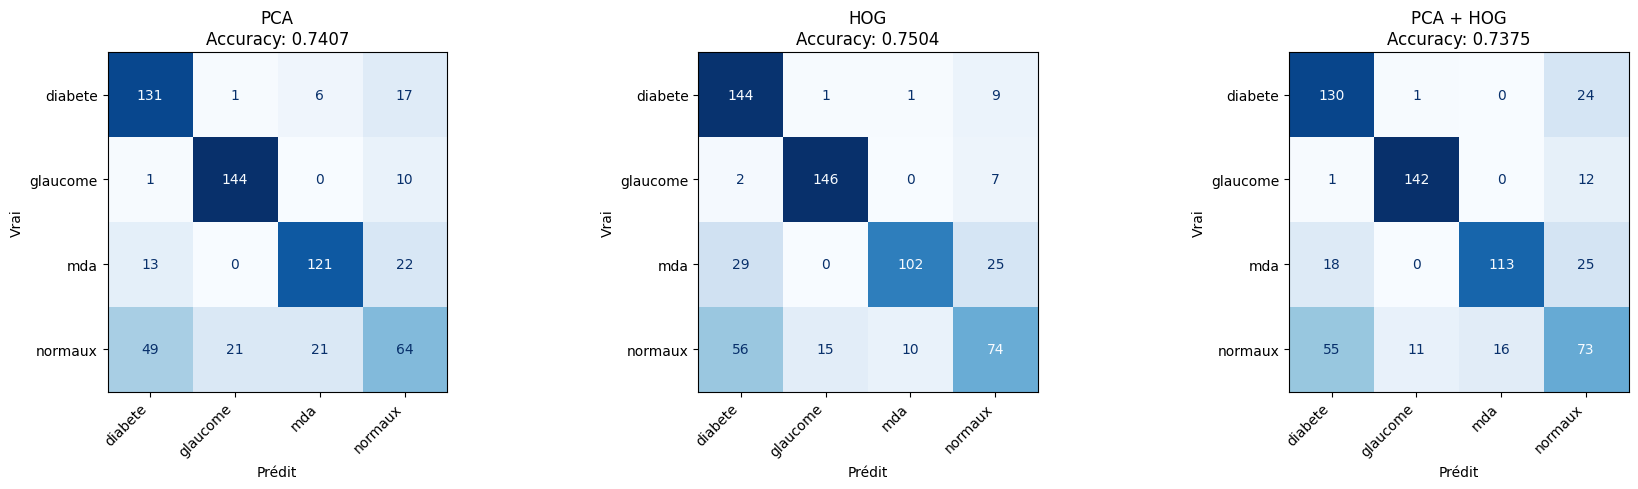

In [ ]:
# Matrices de confusion pour chaque approche
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Rapport de classification détaillé pour la meilleure approche
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: {best_approach}")
print("="*70)

best_data = results[best_approach]
print(f"\nMeilleurs paramètres trouvés:")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification:")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: HOG

Meilleurs paramètres trouvés:
  weights: distance
  n_neighbors: 23
  metric: manhattan

Rapport de classification:
              precision    recall  f1-score   support

     diabete       0.62      0.93      0.75       155
    glaucome       0.90      0.94      0.92       155
         mda       0.90      0.65      0.76       156
     normaux       0.64      0.48      0.55       155

    accuracy                           0.75       621
   macro avg       0.77      0.75      0.74       621
weighted avg       0.77      0.75      0.74       621



In [ ]:
# Graphique comparatif des performances
metrics = ['Val Score', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['Val Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i*width, values, width, label=approach)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features — KNN')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['Val Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    for j, v in enumerate(values):
        ax.text(x[j] + i*width, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VISUALISATION DES ÎLOTS DE DÉCISION KNN (projection PCA 2D)
# ============================================================
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN  # toujours CPU pour la visu

# Palette couleurs par classe
CLASS_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # bleu, orange, vert, rouge
cmap_bg  = ListedColormap([c + '55' for c in CLASS_COLORS])  # fond semi-transparent
cmap_pts = ListedColormap(CLASS_COLORS)                       # points opaques

# Projection PCA 2D sur les pixels
pca2 = PCA(n_components=2, random_state=42)
X_train_2d = pca2.fit_transform(X_train_pixels_scaled)
X_test_2d  = pca2.transform(X_test_pixels_scaled)

k_values     = [1, 5, 15]
weights_list = ['uniform', 'distance']

fig, axes = plt.subplots(len(weights_list), len(k_values), figsize=(18, 11))
fig.suptitle(
    'Îlots de décision KNN — projection PCA 2D (pixels)\n'
    'Points = jeu de test  |  Fond coloré = régions de décision',
    fontsize=14, y=1.01
)

# Grille de décision
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
h = (x_max - x_min) / 300
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

for row_i, w in enumerate(weights_list):
    for col_j, k in enumerate(k_values):
        ax = axes[row_i, col_j]

        knn_2d = SklearnKNN(
            n_neighbors=k, weights=w,
            metric='euclidean', algorithm='ball_tree', n_jobs=-1
        )
        knn_2d.fit(X_train_2d, y_train)

        Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
        ax.contour(xx, yy, Z, colors='white', linewidths=0.4, alpha=0.5)

        ax.scatter(
            X_test_2d[:, 0], X_test_2d[:, 1],
            c=y_test, cmap=cmap_pts,
            edgecolors='k', linewidths=0.4, s=18, alpha=0.85, zorder=3
        )

        acc_2d = accuracy_score(y_test, knn_2d.predict(X_test_2d))
        ax.set_title(f'k={k}  |  weights={w}\nacc_2D={acc_2d:.3f}', fontsize=10)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

# Légende commune
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=CLASS_COLORS[i], markeredgecolor='k',
           markersize=8, label=classes[i])
    for i in range(len(classes))
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=len(classes), fontsize=10,
           bbox_to_anchor=(0.5, -0.03), frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ÎLOTS DE DÉCISION — projection PCA 2D (HOG)
# ============================================================
pca2_hog = PCA(n_components=2, random_state=42)
X_train_hog_2d = pca2_hog.fit_transform(X_train_hog_scaled)
X_test_hog_2d  = pca2_hog.transform(X_test_hog_scaled)

xh_min, xh_max = X_train_hog_2d[:, 0].min() - 1, X_train_hog_2d[:, 0].max() + 1
yh_min, yh_max = X_train_hog_2d[:, 1].min() - 1, X_train_hog_2d[:, 1].max() + 1
hh = (xh_max - xh_min) / 300
xxh, yyh = np.meshgrid(
    np.arange(xh_min, xh_max, hh),
    np.arange(yh_min, yh_max, hh)
)

fig2, axes2 = plt.subplots(len(weights_list), len(k_values), figsize=(18, 11))
fig2.suptitle(
    'Îlots de décision KNN — projection PCA 2D (HOG)\n'
    'Points = jeu de test  |  Fond coloré = régions de décision',
    fontsize=14, y=1.01
)

for row_i, w in enumerate(weights_list):
    for col_j, k in enumerate(k_values):
        ax = axes2[row_i, col_j]

        knn_hog2d = SklearnKNN(
            n_neighbors=k, weights=w,
            metric='euclidean', algorithm='ball_tree', n_jobs=-1
        )
        knn_hog2d.fit(X_train_hog_2d, y_train)

        Zh = knn_hog2d.predict(np.c_[xxh.ravel(), yyh.ravel()])
        Zh = Zh.reshape(xxh.shape)

        ax.contourf(xxh, yyh, Zh, cmap=cmap_bg, alpha=0.6)
        ax.contour(xxh, yyh, Zh, colors='white', linewidths=0.4, alpha=0.5)

        ax.scatter(
            X_test_hog_2d[:, 0], X_test_hog_2d[:, 1],
            c=y_test, cmap=cmap_pts,
            edgecolors='k', linewidths=0.4, s=18, alpha=0.85, zorder=3
        )

        acc_hog2d = accuracy_score(y_test, knn_hog2d.predict(X_test_hog_2d))
        ax.set_title(f'k={k}  |  weights={w}\nacc_2D={acc_hog2d:.3f}', fontsize=10)
        ax.set_xlabel('PC1 (HOG)')
        ax.set_ylabel('PC2 (HOG)')
        ax.set_xlim(xh_min, xh_max)
        ax.set_ylim(yh_min, yh_max)

fig2.legend(handles=legend_elements, loc='lower center',
            ncol=len(classes), fontsize=10,
            bbox_to_anchor=(0.5, -0.03), frameon=True)

plt.tight_layout()
plt.show()